# Task 2 (Segmentation-First Approach)

**Instructions:**
1. Change `CURRENT_TASK` to either `'2a'` (Segmentation) or `'2b'` (Classification)
2. Choose `MODEL_ARCH` from available options for the selected task
3. Run all cells sequentially
4. Results will be automatically saved at the end

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# 🎯 EXPERIMENT CONFIGURATION - CHANGE THESE VALUES TO RUN DIFFERENT EXPERIMENTS
# ═══════════════════════════════════════════════════════════════════════════

CURRENT_TASK = '2b'  # Options: '2a' (Segmentation) or '2b' (Classification)
MODEL_ARCH = 'EfficientNetB0'  # Options for 2a: 'ResNetUNet', 'EfficientUNet', 'AttentionUNet'
                               # Options for 2b: 'EfficientNetB0', 'ResNet18', 'MobileNetV3'

# Hyperparameter Grid (Strictly 8 Combinations)
if CURRENT_TASK == '2a':
    GRID_SEARCH_PARAMS = {
        'learning_rate': [1e-4, 1e-3],
        'use_clahe': [True, False],
        'loss_type': ['dice', 'combo']  # dice = Dice only, combo = Dice + BCE
    }
elif CURRENT_TASK == '2b':
    GRID_SEARCH_PARAMS = {
        'learning_rate': [1e-4, 5e-5],
        'use_clahe': [True, False],
        'dropout_rate': [0.3, 0.6]  # Architecture hyperparameter
    }
else:
    raise ValueError(f"Unknown task: {CURRENT_TASK}")

# Fixed hyperparameters
BATCH_SIZE = 16
IMG_SIZE = 224
OPTIMIZER = 'adamw'

# Training Configuration
NUM_EPOCHS = 50
PATIENCE = 7
LR_PATIENCE = 3
LR_FACTOR = 0.5

# Output Configuration
OUTPUT_DIR = f'experiment_{CURRENT_TASK}_{MODEL_ARCH}'
SAVE_MODEL_PATH = f'{OUTPUT_DIR}/best_model.pth'
SAVE_LOG_PATH = f'{OUTPUT_DIR}/training_log.csv'
SAVE_PLOT_PATH = f'{OUTPUT_DIR}/performance_plot.png'
SAVE_SUMMARY_PATH = f'{OUTPUT_DIR}/experiment_summary.txt'

# Create output directory
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)


print(f"🔬 Experiment Configuration:")
print(f"   Model: {MODEL_ARCH}")

print(f"   Task: {CURRENT_TASK}")
print(f"   Output Directory: {OUTPUT_DIR}")

🔬 Experiment Configuration:
   Model: EfficientNetB0
   Task: 2b
   Output Directory: experiment_2b_EfficientNetB0


# 1- DATA Preprocessing

## DOWNLOAD

In [2]:
import gdown

url = "https://drive.google.com/drive/folders/1uTP8xcNqwi2MYUptg3BZwGjjDOMFhNBC?usp=sharing"
gdown.download_folder(url, output="breast_ultrasound_data", quiet=False)

url = "https://drive.google.com/drive/folders/14EVbUV2WT38i96UAmKF7pd13GyWqu-qR?usp=sharing"
gdown.download_folder(url, output="splits", quiet=False)

Retrieving folder contents


Processing file 1VGohBSMxPSyxJm912O9O-x6fmA-buoSE Training_Images.zip
Processing file 1Oxbq4hGIyU6No9BCiQSsyXL1Dz41R-NU training_metadata.xlsx


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1VGohBSMxPSyxJm912O9O-x6fmA-buoSE
From (redirected): https://drive.google.com/uc?id=1VGohBSMxPSyxJm912O9O-x6fmA-buoSE&confirm=t&uuid=b0ff6e1b-06c9-4726-a53e-7cec9d15b624
To: /kaggle/working/breast_ultrasound_data/Training_Images.zip
100%|██████████| 582M/582M [00:05<00:00, 101MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1Oxbq4hGIyU6No9BCiQSsyXL1Dz41R-NU
To: /kaggle/working/breast_ultrasound_data/training_metadata.xlsx
100%|██████████| 43.9k/43.9k [00:00<00:00, 28.0MB/s]
Download completed
Retrieving folder contents


Processing file 1eHpZZliVD3id0_882NA4mQ4bC-0IR5Uw fold_0_train.csv
Processing file 1xJx7b1XnSOVwoi5CLmhWWegRjd9d987x fold_0_val.csv
Processing file 104L5nzPP5OsFUB_k80UwQhfQSdieFa81 fold_1_train.csv
Processing file 1EsHJUU14Hy4YLNFPwPrMxPdH1CANyZ4K fold_1_val.csv
Processing file 1-nw-dwBodjx_WElic_7fYGUpAYE_o1ew fold_2_train.csv
Processing file 18UuKP8iotw-zQhgsD2XcckYenIgmq3QL fold_2_val.csv
Processing file 1mhNj2iPZsSAuj7yC4ijgLiolbObPeWbr fold_3_train.csv
Processing file 1BMs5bEqgL3C4CqXj8_qh24TsIRK0dfYW fold_3_val.csv
Processing file 1gmQ6DKFtZhTFcGdfnZmC3n9bUX70_d-0 fold_4_train.csv
Processing file 1FYlevjQ_84GZyHYyeSWcLt0cbVU3DXyW fold_4_val.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eHpZZliVD3id0_882NA4mQ4bC-0IR5Uw
To: /kaggle/working/splits/fold_0_train.csv
100%|██████████| 35.9k/35.9k [00:00<00:00, 46.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xJx7b1XnSOVwoi5CLmhWWegRjd9d987x
To: /kaggle/working/splits/fold_0_val.csv
100%|██████████| 9.03k/9.03k [00:00<00:00, 12.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=104L5nzPP5OsFUB_k80UwQhfQSdieFa81
To: /kaggle/working/splits/fold_1_train.csv
100%|██████████| 35.9k/35.9k [00:00<00:00, 41.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EsHJUU14Hy4YLNFPwPrMxPdH1CANyZ4K
To: /kaggle/working/splits/fold_1_val.csv
100%|██████████| 9.04k/9.04k [00:00<00:00, 14.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-nw-dwBodjx_WElic_7fYGUpAYE_o1ew
To: /kaggle/working/splits/fold_2_train.csv
100%|██████████| 35.9k/35.9k [00:00<0

['splits/fold_0_train.csv',
 'splits/fold_0_val.csv',
 'splits/fold_1_train.csv',
 'splits/fold_1_val.csv',
 'splits/fold_2_train.csv',
 'splits/fold_2_val.csv',
 'splits/fold_3_train.csv',
 'splits/fold_3_val.csv',
 'splits/fold_4_train.csv',
 'splits/fold_4_val.csv']

## UNZIP

In [3]:
import zipfile
import os

zip_path = "breast_ultrasound_data/Training_Images.zip"
extract_to = "breast_ultrasound_data/training_images"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipped files:", len(os.listdir(extract_to)))

Unzipped files: 1


## Load Pre-Split Data from CSV

In [4]:
import pandas as pd
import numpy as np
from PIL import Image

# ═══════════════════════════════════════════════════════════════════════════
# FOLD CONFIGURATION - Change this to train on different folds
# ═══════════════════════════════════════════════════════════════════════════
FOLD = 0  # Options: 0, 1, 2, 3, 4

# Paths
SPLITS_DIR = "splits"
image_folder = "breast_ultrasound_data/training_images/training_images"

# ═══════════════════════════════════════════════════════════════════════════
# LOAD PRE-SPLIT DATA FROM CSV
# ═══════════════════════════════════════════════════════════════════════════
print(f"{'='*60}")
print(f"LOADING PRE-SPLIT DATA (Fold {FOLD})")
print(f"{'='*60}")

train_df = pd.read_csv(f'{SPLITS_DIR}/fold_{FOLD}_train.csv')
val_df = pd.read_csv(f'{SPLITS_DIR}/fold_{FOLD}_val.csv')

# ═══════════════════════════════════════════════════════════════════════════
# DESERIALIZE MASK FILENAMES (CSV stores lists as semicolon-separated strings)
# ═══════════════════════════════════════════════════════════════════════════
train_df['mask_filenames_list'] = train_df['mask_filenames'].apply(lambda x: str(x).split(';'))
val_df['mask_filenames_list'] = val_df['mask_filenames'].apply(lambda x: str(x).split(';'))

# ═══════════════════════════════════════════════════════════════════════════
# SUMMARY
# ═══════════════════════════════════════════════════════════════════════════
print(f"\n✓ Train: {len(train_df)} images, {train_df['patient_id'].nunique()} patients")
print(f"  Labels: {dict(train_df['label'].value_counts().sort_index())}")
print(f"\n✓ Val:   {len(val_df)} images, {val_df['patient_id'].nunique()} patients")
print(f"  Labels: {dict(val_df['label'].value_counts().sort_index())}")

# Verify no patient overlap
train_patients = set(train_df['patient_id'].unique())
val_patients = set(val_df['patient_id'].unique())
assert len(train_patients & val_patients) == 0, "Patient leak detected!"
print(f"\n✓ No patient overlap between Train and Val")
print(f"{'='*60}")

LOADING PRE-SPLIT DATA (Fold 0)

✓ Train: 1202 images, 774 patients
  Labels: {0: np.int64(540), 1: np.int64(279), 2: np.int64(383)}

✓ Val:   301 images, 194 patients
  Labels: {0: np.int64(139), 1: np.int64(85), 2: np.int64(77)}

✓ No patient overlap between Train and Val


# 2- Model and Data Loader Implementation

## Augmentation Pipeline

In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

def get_transforms(train=True, img_size=224, use_CLAHE=False):
    if train:
        transforms = [
            A.Resize(height=img_size, width=img_size),
            A.HorizontalFlip(p=0.5),
            A.Affine(
                scale=(0.9, 1.1),
                translate_percent=(-0.0625, 0.0625),
                rotate=(-15, 15),
                p=0.5
            ),
            A.OneOf([
                A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05),
                A.GridDistortion(p=0.5),
            ], p=0.3),
            A.OneOf([
                A.GaussNoise(p=0.5),
                A.RandomBrightnessContrast(p=0.5),
            ], p=0.3),
        ]

        if use_CLAHE:
            transforms.append(A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5))

        transforms.extend([
            A.Normalize(mean=(0.5,), std=(0.5,)),
            ToTensorV2()
        ])

        return A.Compose(transforms)
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.5,), std=(0.5,)),
            ToTensorV2()
        ])

## Dataset Classes

In [6]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class BreastLesionSegmentationDataset(Dataset):
    """Dataset for Task 2a - Segmentation (All images)"""
    def __init__(self, dataframe, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # Data is already grouped by image_filename from CSV
        # Uses 'mask_filenames_list' column (list of mask filenames)
        self.data = dataframe.dropna(subset=['label']).reset_index(drop=True)

        print(f"Task 2a Dataset: {len(self.data)} unique images")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_name = row['image_filename']
        mask_names = row['mask_filenames_list']  # Already a list from deserialization
        label = row['label']

        # Load Image
        img_path = os.path.join(self.image_dir, img_name)
        image = np.array(Image.open(img_path).convert("L"))

        # Load and Combine All Masks (Worst-Case Logic)
        if label == 2:  # Normal (no lesions)
            mask = np.zeros_like(image, dtype=np.float32)
        else:
            # Initialize empty mask
            mask = np.zeros_like(image, dtype=np.float32)

            # Load all masks and combine using maximum (union of all lesions)
            for mask_name in mask_names:
                mask_path = os.path.join(self.image_dir, mask_name)
                if os.path.exists(mask_path):
                    single_mask = np.array(Image.open(mask_path).convert("L"))
                    single_mask = (single_mask > 127).astype(np.float32)
                    mask = np.maximum(mask, single_mask)  # Union of all lesions

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Add channel dimension if needed
        if image.ndim == 2:
            image = image.unsqueeze(0)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask, label


class BreastLesionClassificationDataset(Dataset):
    """Dataset for Task 2b - Binary Classification (Benign vs Malignant ONLY)

    Uses FIRST mask from the list for each image.
    """
    def __init__(self, dataframe, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # Drop any NaN labels first
        clean_df = dataframe.dropna(subset=['label']).copy()

        # Filter out Normal images (label=2) for binary classification
        self.data = clean_df[clean_df['label'] != 2].reset_index(drop=True)

        # Ensure labels are integers
        self.data['label'] = self.data['label'].astype(int)

        print(f"Task 2b Dataset: {len(self.data)} images (B/M only, Normal excluded)")

        if len(self.data) == 0:
            print(f"⚠️  WARNING: No B/M images found!")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_name = row['image_filename']
        mask_names = row['mask_filenames_list']  # List of mask filenames
        label = row['label']  # 0=Benign, 1=Malignant

        # Load Image
        img_path = os.path.join(self.image_dir, img_name)
        image = np.array(Image.open(img_path).convert("L"))

        # Load and combine all masks (union of all lesions)
        mask = np.zeros_like(image, dtype=np.float32)
        for mask_name in mask_names:
            mask_path = os.path.join(self.image_dir, mask_name)
            if os.path.exists(mask_path):
                single_mask = np.array(Image.open(mask_path).convert("L"))
                single_mask = (single_mask > 127).astype(np.float32)
                mask = np.maximum(mask, single_mask)

        # Apply mask to image (keep only lesion regions)
        masked_image = image * mask

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=masked_image)
            image = augmented['image']

        # Add channel dimension if needed
        if image.ndim == 2:
            image = image.unsqueeze(0)

        return image, int(label)

# 3- Model Architectures

## Segmentation Models (Task 2a)

In [7]:
# Install segmentation models library
!pip install segmentation-models-pytorch -q

# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import segmentation_models_pytorch as smp

print("✓ segmentation_models_pytorch installed successfully!")
print(f"   Version: {smp.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✓ segmentation_models_pytorch installed successfully!
   Version: 0.5.0


## Classification Models (Task 2b)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CLASSIFICATION MODELS (Task 2b)
# ═══════════════════════════════════════════════════════════════════════════

# Note: Classification models are now created directly in the get_model() factory function
# This ensures proper channel modification and dropout configuration

print("✓ Classification models ready (EfficientNetB0, ResNet18, MobileNetV3)")
print("  Models will be created with pretrained ImageNet weights")
print("  First conv layer modified for grayscale (1 channel) input")

✓ Classification models ready (EfficientNetB0, ResNet18, MobileNetV3)
  Models will be created with pretrained ImageNet weights
  First conv layer modified for grayscale (1 channel) input


## Model Factory

In [9]:
def get_model(task_type, model_name, dropout_rate=0.0):
    """
    Factory function to get the correct model based on task and architecture.

    Args:
        task_type (str): '2a' (Segmentation) or '2b' (Classification)
        model_name (str): Model architecture name
        dropout_rate (float): Dropout rate for classification models (ignored for segmentation)

    Returns:
        torch.nn.Module: The requested model
    """

    if task_type == '2a':
        # ═══════════════════════════════════════════════════════════════
        # SEGMENTATION MODELS (Transfer Learning with pretrained encoders)
        # ═══════════════════════════════════════════════════════════════

        if model_name == 'ResNetUNet':
            # U-Net with ResNet34 backbone
            base_model = smp.Unet(
                encoder_name='resnet34',
                encoder_weights='imagenet',
                in_channels=1,
                classes=1,
                activation=None
            )

        elif model_name == 'EfficientUNet':
            # U-Net with EfficientNet-B0 backbone (lightweight)
            base_model = smp.Unet(
                encoder_name='efficientnet-b0',
                encoder_weights='imagenet',
                in_channels=1,
                classes=1,
                activation=None
            )

        elif model_name == 'AttentionUNet':
            # U-Net++ (Nested U-Net) with ResNet34 backbone
            base_model = smp.UnetPlusPlus(
                encoder_name='resnet34',
                encoder_weights='imagenet',
                in_channels=1,
                classes=1,
                activation=None
            )

        else:
            raise ValueError(f"Unknown segmentation model: {model_name}")

        # Wrapper to apply sigmoid activation
        class SegmentationModelWrapper(nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model

            def forward(self, x):
                return torch.sigmoid(self.model(x))

        return SegmentationModelWrapper(base_model)

    elif task_type == '2b':
        # ═══════════════════════════════════════════════════════════════
        # CLASSIFICATION MODELS (Binary: Benign vs Malignant)
        # ═══════════════════════════════════════════════════════════════

        if model_name == 'EfficientNetB0':
            weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
            model = models.efficientnet_b0(weights=weights)

            # Modify first conv for grayscale (1 channel)
            model.features[0][0] = nn.Conv2d(
                1, 32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            )

            # Modify classifier with dropout
            in_features = model.classifier[1].in_features
            model.classifier = nn.Sequential(
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, 2)
            )
            return model

        elif model_name == 'ResNet18':
            weights = models.ResNet18_Weights.IMAGENET1K_V1
            model = models.resnet18(weights=weights)

            # Modify first conv for grayscale (1 channel)
            model.conv1 = nn.Conv2d(
                1, 64,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            )

            # Modify final layer with dropout
            in_features = model.fc.in_features
            model.fc = nn.Sequential(
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, 2)
            )
            return model

        elif model_name == 'MobileNetV3':
            weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
            model = models.mobilenet_v3_small(weights=weights)

            # Modify first conv for grayscale (1 channel)
            model.features[0][0] = nn.Conv2d(
                1, 16,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            )

            # Modify classifier with dropout
            in_features = model.classifier[3].in_features
            model.classifier[3] = nn.Sequential(
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, 2)
            )
            return model

        else:
            raise ValueError(f"Unknown classification model: {model_name}")

    else:
        raise ValueError(f"Unknown task type: {task_type}")


# Test the factory
print("Testing Model Factory:")
test_model = get_model(CURRENT_TASK, MODEL_ARCH)
print(f"✓ Successfully created {MODEL_ARCH} for Task {CURRENT_TASK}")
print(f"  Total parameters: {sum(p.numel() for p in test_model.parameters()):,}")
del test_model

Testing Model Factory:
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]

✓ Successfully created EfficientNetB0 for Task 2b
  Total parameters: 4,009,534


# 4- Training Components

## Loss Functions and Metrics

In [10]:
import torch
import torch.nn as nn
from sklearn.metrics import balanced_accuracy_score

# ═══════════════════════════════════════════════════════════════════════════
# SEGMENTATION LOSS & METRICS
# ═══════════════════════════════════════════════════════════════════════════

class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, pred, target):
        smooth = 1e-5
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
        return dice_loss


class DiceBCELoss(nn.Module):
    """Combined Dice + BCE Loss for segmentation"""
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super(DiceBCELoss, self).__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        # Dice Loss
        smooth = 1e-5
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

        # BCE Loss
        bce_loss = self.bce(pred, target)

        return self.dice_weight * dice_loss + self.bce_weight * bce_loss


def dice_coefficient(pred, target, smooth=1e-5):
    """Calculate Dice coefficient"""
    pred = (pred > 0.5).float()
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


# ═══════════════════════════════════════════════════════════════════════════
# CLASSIFICATION LOSS & METRICS
# ═══════════════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """Focal Loss for classification"""
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def balanced_accuracy(y_true, y_pred):
    """Calculate balanced accuracy"""
    return balanced_accuracy_score(y_true.cpu().numpy(), y_pred.cpu().numpy())

## Early Stopping

In [11]:
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=7, min_delta=0.0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
            self.counter = 0
            if self.verbose:
                print(f"  ✓ Validation loss improved to {val_loss:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  ✗ No improvement. Patience: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  Early stopping triggered!")

    def load_best_model(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
        return model

## Training Functions

In [12]:
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ═══════════════════════════════════════════════════════════════════════════
# SEGMENTATION TRAINING
# ═══════════════════════════════════════════════════════════════════════════

def train_segmentation_model(model, train_loader, val_loader, epochs=50, lr=1e-4,
                             device='cuda', patience=7, lr_patience=3, lr_factor=0.5,
                             optimizer='adamw', weight_decay=1e-4, loss_type='combo'):
    """Train a segmentation model"""
    model = model.to(device)

    # Optimizer
    if optimizer.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    # Loss function based on loss_type
    if loss_type == 'dice':
        criterion = DiceLoss()
    elif loss_type == 'combo':
        criterion = DiceBCELoss()
    else:
        raise ValueError(f"Unsupported loss_type: {loss_type}")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=lr_factor, patience=lr_patience)
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    history = {
        'train_loss': [],
        'train_dice': [],
        'val_loss': [],
        'val_dice': [],
        'learning_rate': []
    }

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_dice = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, masks, _ in loop:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_coefficient(outputs.detach(), masks).item()
            loop.set_postfix(loss=loss.item())

        # Validation
        model.eval()
        val_loss = 0
        val_dice = 0

        with torch.no_grad():
            for images, masks, _ in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                val_dice += dice_coefficient(outputs, masks).item()

        # Calculate averages
        avg_train_loss = train_loss / len(train_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train_loss)
        history['train_dice'].append(avg_train_dice)
        history['val_loss'].append(avg_val_loss)
        history['val_dice'].append(avg_val_dice)
        history['learning_rate'].append(current_lr)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Dice: {avg_train_dice:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f} | "
              f"LR: {current_lr:.2e}")

        scheduler.step(avg_val_loss)
        early_stopping(avg_val_loss, model)

        if early_stopping.early_stop:
            print(f"\nStopping early at epoch {epoch+1}")
            break

    model = early_stopping.load_best_model(model)
    return model, history


# ═══════════════════════════════════════════════════════════════════════════
# CLASSIFICATION TRAINING
# ═══════════════════════════════════════════════════════════════════════════

def train_classification_model(model, train_loader, val_loader, epochs=50, lr=1e-4,
                               device='cuda', patience=7, lr_patience=3, lr_factor=0.5,
                               optimizer='adamw', weight_decay=1e-4):
    """Train a binary classification model"""
    model = model.to(device)

    # Optimizer
    if optimizer.lower() == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    criterion = nn.CrossEntropyLoss()
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=lr_factor, patience=lr_patience)
    early_stopping = EarlyStopping(patience=patience, verbose=True)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rate': []
    }

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            loop.set_postfix(loss=loss.item())

        # Validation
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()

        # Calculate averages
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * correct / total
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct_val / total_val
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(current_lr)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.2e}")

        scheduler.step(avg_val_loss)
        early_stopping(avg_val_loss, model)

        if early_stopping.early_stop:
            print(f"\nStopping early at epoch {epoch+1}")
            break

    model = early_stopping.load_best_model(model)
    return model, history

# 5- Experiment Execution

## Grid Search Runner

In [13]:
import itertools
from torch.utils.data import DataLoader

# Generate parameter combinations (Strictly 8)
param_combinations = list(itertools.product(
    GRID_SEARCH_PARAMS['learning_rate'],
    GRID_SEARCH_PARAMS['use_clahe'],
    GRID_SEARCH_PARAMS.get('loss_type', [None]) if CURRENT_TASK == '2a' else GRID_SEARCH_PARAMS.get('dropout_rate', [0.3])
))

print(f"\n{'='*60}")
print(f"GRID SEARCH: {len(param_combinations)} combinations (STRICT)")
print(f"Task: {CURRENT_TASK} | Model: {MODEL_ARCH}")
print(f"Fixed: BS={BATCH_SIZE}, IMG={IMG_SIZE}, OPT={OPTIMIZER}")
print(f"{'='*60}\n")

# Storage for results
results = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

# Track the best model across ALL grid search combinations
best_overall_score = -float('inf')  # For metrics we want to maximize (Dice, Accuracy)
best_overall_model_state = None
best_params = {}
best_history = None

# Run grid search
for idx, (lr, use_clahe, task_specific_param) in enumerate(param_combinations):
    print(f"\n{'='*60}")
    print(f"Combination {idx+1}/{len(param_combinations)}")
    if CURRENT_TASK == '2a':
        loss_type = task_specific_param
        dropout_rate = 0.0
        print(f"LR={lr}, CLAHE={use_clahe}, LOSS={loss_type}")
    else:
        loss_type = 'combo'
        dropout_rate = task_specific_param
        print(f"LR={lr}, CLAHE={use_clahe}, DROPOUT={dropout_rate}")
    print(f"{'='*60}")

    try:
        # Prepare data loaders
        if CURRENT_TASK == '2a':
            # Segmentation
            train_ds = BreastLesionSegmentationDataset(
                train_df, image_folder,
                transform=get_transforms(train=True, img_size=IMG_SIZE, use_CLAHE=use_clahe)
            )
            val_ds = BreastLesionSegmentationDataset(
                val_df, image_folder,
                transform=get_transforms(train=False, img_size=IMG_SIZE, use_CLAHE=use_clahe)
            )
        else:
            # Classification (2b)
            train_ds = BreastLesionClassificationDataset(
                train_df, image_folder,
                transform=get_transforms(train=True, img_size=IMG_SIZE, use_CLAHE=use_clahe)
            )
            val_ds = BreastLesionClassificationDataset(
                val_df, image_folder,
                transform=get_transforms(train=False, img_size=IMG_SIZE, use_CLAHE=use_clahe)
            )

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)

        # Create model (with dropout for classification)
        model = get_model(CURRENT_TASK, MODEL_ARCH, dropout_rate=dropout_rate).to(device)

        # Train model
        if CURRENT_TASK == '2a':
            model, history = train_segmentation_model(
                model, train_loader, val_loader,
                epochs=NUM_EPOCHS, lr=lr, device=device,
                patience=PATIENCE, lr_patience=LR_PATIENCE, lr_factor=LR_FACTOR,
                optimizer=OPTIMIZER, loss_type=loss_type
            )
            best_metric = max(history['val_dice'])
            metric_name = 'val_dice'
        else:
            model, history = train_classification_model(
                model, train_loader, val_loader,
                epochs=NUM_EPOCHS, lr=lr, device=device,
                patience=PATIENCE, lr_patience=LR_PATIENCE, lr_factor=LR_FACTOR,
                optimizer=OPTIMIZER
            )
            best_metric = max(history['val_acc'])
            metric_name = 'val_acc'

        # Store results
        result = {
            'learning_rate': lr,
            'use_clahe': use_clahe,
            metric_name: best_metric,
        }

        if CURRENT_TASK == '2a':
            result['loss_type'] = loss_type
        else:
            result['dropout_rate'] = dropout_rate

        results.append(result)
        print(f"\n✓ {metric_name.upper()}: {best_metric:.4f}")

        # ═══════════════════════════════════════════════════════════════
        # 🏆 TRACK BEST MODEL ACROSS ALL COMBINATIONS
        # ═══════════════════════════════════════════════════════════════
        if best_metric > best_overall_score:
            best_overall_score = best_metric
            best_overall_model_state = model.state_dict().copy()
            best_params = {
                'learning_rate': lr,
                'use_clahe': use_clahe,
                'metric_name': metric_name,
                'best_score': best_metric
            }
            if CURRENT_TASK == '2a':
                best_params['loss_type'] = loss_type
            else:
                best_params['dropout_rate'] = dropout_rate
            best_history = history
            print(f"\n🏆 NEW BEST MODEL (Score: {best_metric:.4f})")

        # Cleanup
        del model, train_ds, val_ds, train_loader, val_loader
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n✗ Error: {e}")
        import traceback
        traceback.print_exc()
        torch.cuda.empty_cache()
        continue

# Check results
if len(results) == 0:
    raise RuntimeError("No successful training runs. Check errors above.")

print(f"\n{'='*60}")
print("GRID SEARCH COMPLETED")
print(f"{'='*60}\n")

# Save the best model from grid search
if best_overall_model_state is None:
    raise RuntimeError("No best model was saved during grid search.")

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.save(best_overall_model_state, SAVE_MODEL_PATH)

print(f"{'='*60}")
print(f"\n🏆 OVERALL BEST MODEL SAVED:")
print(f"   Score: {best_overall_score:.4f}")
print(f"   Params: LR={best_params['learning_rate']}, CLAHE={best_params['use_clahe']}")
if CURRENT_TASK == '2a':
    print(f"            LOSS={best_params['loss_type']}")
else:

    print(f"            DROPOUT={best_params['dropout_rate']}")
    print(f"{'='*60}")
print(f"   Model: {SAVE_MODEL_PATH}")


GRID SEARCH: 8 combinations (STRICT)
Task: 2b | Model: EfficientNetB0
Fixed: BS=16, IMG=224, OPT=adamw

Device: cuda


Combination 1/8
LR=0.0001, CLAHE=True, DROPOUT=0.3
Task 2b Dataset: 819 images (B/M only, Normal excluded)
Task 2b Dataset: 224 images (B/M only, Normal excluded)


Epoch 1/50: 100%|██████████| 52/52 [00:09<00:00,  5.75it/s, loss=0.413]


Epoch 01/50 | Train Loss: 0.5725 | Train Acc: 70.33% | Val Loss: 0.6303 | Val Acc: 61.61% | LR: 1.00e-04


Epoch 2/50: 100%|██████████| 52/52 [00:07<00:00,  7.31it/s, loss=0.181]


Epoch 02/50 | Train Loss: 0.4418 | Train Acc: 80.34% | Val Loss: 0.5027 | Val Acc: 76.79% | LR: 1.00e-04
  ✓ Validation loss improved to 0.5027


...

Epoch 18/50 | Train Loss: 0.2309 | Train Acc: 90.96% | Val Loss: 0.3026 | Val Acc: 88.39% | LR: 2.50e-05
  ✗ No improvement. Patience: 5/7


Epoch 19/50: 100%|██████████| 52/52 [00:06<00:00,  8.21it/s, loss=0.119]


Epoch 19/50 | Train Loss: 0.2302 | Train Acc: 91.09% | Val Loss: 0.3371 | Val Acc: 88.39% | LR: 2.50e-05
  ✗ No improvement. Patience: 6/7


Epoch 20/50: 100%|██████████| 52/52 [00:06<00:00,  8.23it/s, loss=0.0116]


Epoch 20/50 | Train Loss: 0.2015 | Train Acc: 91.70% | Val Loss: 0.3105 | Val Acc: 88.39% | LR: 2.50e-05
  ✗ No improvement. Patience: 7/7
  Early stopping triggered!

Stopping early at epoch 20

✓ VAL_ACC: 89.7321

GRID SEARCH COMPLETED


🏆 OVERALL BEST MODEL SAVED:
   Score: 90.1786
   Params: LR=0.0001, CLAHE=False
            DROPOUT=0.6
   Model: experiment_2b_EfficientNetB0/best_model.pth


## Grid Search Summary

In [14]:
# Create DataFrame and sort
results_df = pd.DataFrame(results)
metric_col = 'val_dice' if CURRENT_TASK == '2a' else 'val_acc'
results_df = results_df.sort_values(metric_col, ascending=False)

print("="*70)
print("GRID SEARCH RESULTS SUMMARY")
print("="*70)
print(results_df.to_string())
print()

# Display best configuration (already saved during grid search)
print(f"\n{'='*70}")
print("🏆 BEST MODEL CONFIGURATION (Already Saved)")
print(f"{'='*70}")
print(f"   Learning Rate: {best_params['learning_rate']}")
print(f"   Use CLAHE: {best_params['use_clahe']}")
if CURRENT_TASK == '2a':
    print(f"   Loss Type: {best_params['loss_type']}")
else:
    print(f"   Dropout Rate: {best_params['dropout_rate']}")
print(f"   Best {metric_col}: {best_params['best_score']:.4f}")
print(f"\n   Model saved at: {SAVE_MODEL_PATH}")
print(f"{'='*70}\n")

# Prepare final evaluation loaders with best hyperparameters
print("Preparing validation loader for final evaluation...")

if CURRENT_TASK == '2a':
    val_ds_final = BreastLesionSegmentationDataset(
        val_df, image_folder,
        transform=get_transforms(train=False, img_size=IMG_SIZE,
                                use_CLAHE=best_params['use_clahe'])
    )
else:
    val_ds_final = BreastLesionClassificationDataset(
        val_df, image_folder,
        transform=get_transforms(train=False, img_size=IMG_SIZE,
                                use_CLAHE=best_params['use_clahe'])
    )

val_loader_final = DataLoader(val_ds_final, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
print("✓ Validation loader ready.\n")


GRID SEARCH RESULTS SUMMARY
   learning_rate  use_clahe    val_acc  dropout_rate
3        0.00010      False  90.178571           0.6
6        0.00005      False  90.178571           0.3
7        0.00005      False  89.732143           0.6
1        0.00010       True  89.285714           0.6
5        0.00005       True  89.285714           0.6
0        0.00010       True  87.946429           0.3
2        0.00010      False  87.946429           0.3
4        0.00005       True  85.714286           0.3


🏆 BEST MODEL CONFIGURATION (Already Saved)
   Learning Rate: 0.0001
   Use CLAHE: False
   Dropout Rate: 0.6
   Best val_acc: 90.1786

   Model saved at: experiment_2b_EfficientNetB0/best_model.pth

Preparing validation loader for final evaluation...
Task 2b Dataset: 224 images (B/M only, Normal excluded)
✓ Validation loader ready.



# 6- Save Results and Final Evaluation

## Load Best Model for Evaluation

In [15]:
print("\n" + "="*70)
print("LOADING BEST MODEL FOR FINAL EVALUATION")
print("="*70)

# Create model with correct dropout_rate for classification
if CURRENT_TASK == '2b':
    dropout_rate_best = best_params.get('dropout_rate', 0.3)
else:
    dropout_rate_best = 0.0

final_model = get_model(CURRENT_TASK, MODEL_ARCH, dropout_rate=dropout_rate_best).to(device)
final_model.load_state_dict(torch.load(SAVE_MODEL_PATH))
final_model.eval()

print(f"✓ Best model loaded from: {SAVE_MODEL_PATH}")
print(f"✓ Model architecture: {MODEL_ARCH}")
print(f"✓ Total parameters: {sum(p.numel() for p in final_model.parameters()):,}")

# Use the history from the best model (saved during grid search)
final_history = best_history



LOADING BEST MODEL FOR FINAL EVALUATION
✓ Best model loaded from: experiment_2b_EfficientNetB0/best_model.pth
✓ Model architecture: EfficientNetB0
✓ Total parameters: 4,009,534


## Save Training Log

In [16]:
# Create and save training log from best model
log_df = pd.DataFrame(final_history)
log_df['epoch'] = range(1, len(log_df) + 1)
log_df.to_csv(SAVE_LOG_PATH, index=False)
print(f"\n✓ Training log saved to: {SAVE_LOG_PATH}")
print("\nLast 5 epochs of training:")
print(log_df.tail())


✓ Training log saved to: experiment_2b_EfficientNetB0/training_log.csv

Last 5 epochs of training:
    train_loss  train_acc  val_loss    val_acc  learning_rate  epoch
21    0.247826  88.888889  0.337245  87.053571        0.00010     22
22    0.257501  91.697192  0.356799  86.160714        0.00010     23
23    0.242917  90.354090  0.382935  87.946429        0.00005     24
24    0.203903  91.575092  0.341307  87.946429        0.00005     25
25    0.194809  92.307692  0.326047  90.178571        0.00005     26


## Generate Performance Plot

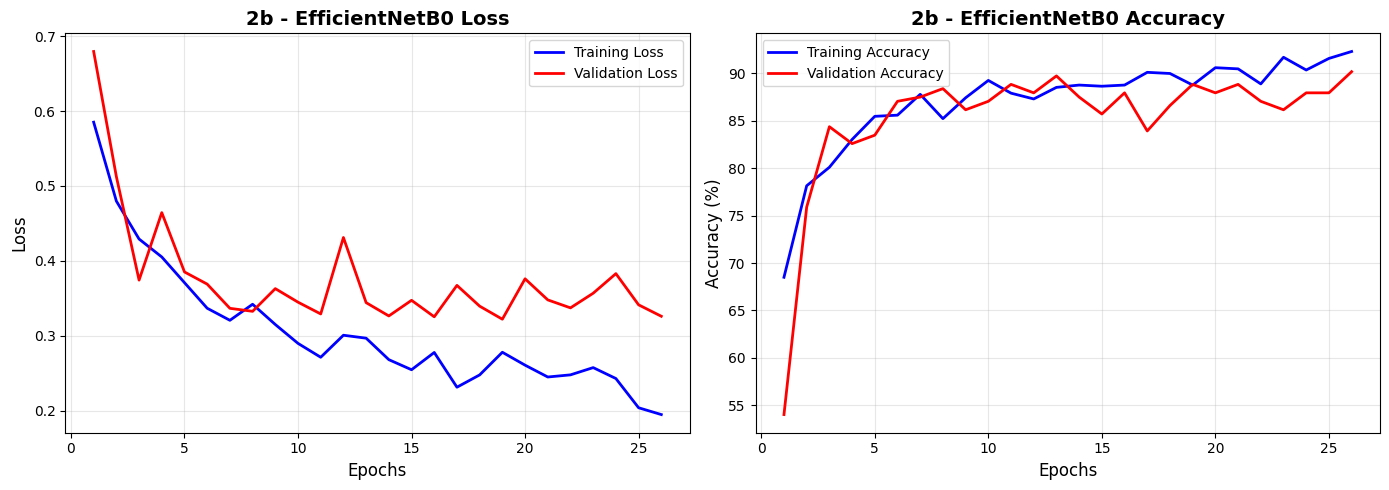

✓ Performance plot saved to: experiment_2b_EfficientNetB0/performance_plot.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(final_history['train_loss']) + 1)

# Plot Loss
axes[0].plot(epochs, final_history['train_loss'], 'b-', label='Training Loss', linewidth=2)
axes[0].plot(epochs, final_history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[0].set_title(f'{CURRENT_TASK} - {MODEL_ARCH} Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot Metric (Dice or Accuracy)
if CURRENT_TASK == '2a':
    axes[1].plot(epochs, final_history['train_dice'], 'b-', label='Training Dice', linewidth=2)
    axes[1].plot(epochs, final_history['val_dice'], 'r-', label='Validation Dice', linewidth=2)
    axes[1].set_ylabel('Dice Score', fontsize=12)
    axes[1].set_title(f'{CURRENT_TASK} - {MODEL_ARCH} Dice Score', fontsize=14, fontweight='bold')
else:
    axes[1].plot(epochs, final_history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
    axes[1].plot(epochs, final_history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title(f'{CURRENT_TASK} - {MODEL_ARCH} Accuracy', fontsize=14, fontweight='bold')

axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Performance plot saved to: {SAVE_PLOT_PATH}")

## Generate Experiment Summary

In [18]:
# Generate comprehensive summary
summary_lines = [
    "="*70,
    f"EXPERIMENT SUMMARY - Task {CURRENT_TASK}",
    "="*70,
    "",
    "CONFIGURATION:",
    f"  Task Type: {CURRENT_TASK}",
    f"  Model Architecture: {MODEL_ARCH}",
    f"  Total Parameters: {sum(p.numel() for p in final_model.parameters()):,}",
    "",
    "HYPERPARAMETERS:",
    f"  Batch Size: {BATCH_SIZE}",
    f"  Image Size: {IMG_SIZE}",
    f"  Optimizer: {OPTIMIZER}",
    "",
    "BEST GRID SEARCH CONFIGURATION:",
    f"  Learning Rate: {best_params['learning_rate']}",
    f"  Use CLAHE: {best_params['use_clahe']}",
]

if CURRENT_TASK == '2a':
    summary_lines.append(f"  Loss Type: {best_params['loss_type']}")
else:
    summary_lines.append(f"  Dropout Rate: {best_params['dropout_rate']}")

summary_lines.extend([
    "",
    "TRAINING RESULTS:",
    f"  Total Epochs: {len(final_history['train_loss'])}",
    f"  Final Train Loss: {final_history['train_loss'][-1]:.4f}",
    f"  Final Val Loss: {final_history['val_loss'][-1]:.4f}",
])

if CURRENT_TASK == '2a':
    summary_lines.extend([
        f"  Final Train Dice: {final_history['train_dice'][-1]:.4f}",
        f"  Final Val Dice: {final_history['val_dice'][-1]:.4f}",
        f"  Best Val Dice: {max(final_history['val_dice']):.4f}",
    ])
else:
    summary_lines.extend([
        f"  Final Train Acc: {final_history['train_acc'][-1]:.2f}%",
        f"  Final Val Acc: {final_history['val_acc'][-1]:.2f}%",
        f"  Best Val Acc: {max(final_history['val_acc']):.2f}%",
    ])

summary_lines.extend([
    "",
    "GRID SEARCH RESULTS:",
    f"  Total Combinations Tested: {len(results)}",
    f"  Successful Runs: {len(results)}",
    f"  Best Model Score: {best_params['best_score']:.4f}",
    "",
    "TOP 3 CONFIGURATIONS:",
])

metric_col = 'val_dice' if CURRENT_TASK == '2a' else 'val_acc'
for idx, (i, row) in enumerate(results_df.head(3).iterrows(), start=1):
    metric_val = row[metric_col]
    if CURRENT_TASK == '2a':
        summary_lines.append(
            f"  #{idx}: LR={row['learning_rate']}, CLAHE={row['use_clahe']}, "
            f"LOSS={row['loss_type']}, {metric_col}={metric_val:.4f}"
        )
    else:
        summary_lines.append(
            f"  #{idx}: LR={row['learning_rate']}, CLAHE={row['use_clahe']}, "
            f"DROPOUT={row['dropout_rate']}, {metric_col}={metric_val:.4f}"
        )

summary_lines.extend([
    "",
    "OUTPUT FILES:",
    f"  Model: {SAVE_MODEL_PATH}",
    f"  Log: {SAVE_LOG_PATH}",
    f"  Plot: {SAVE_PLOT_PATH}",
    f"  Summary: {SAVE_SUMMARY_PATH}",
    "",
    "="*70,
])

summary_text = "\n".join(summary_lines)

# Save to file
with open(SAVE_SUMMARY_PATH, 'w') as f:
    f.write(summary_text)

# Print to console
print(summary_text)
print(f"\n✓ Experiment summary saved to: {SAVE_SUMMARY_PATH}")

EXPERIMENT SUMMARY - Task 2b

CONFIGURATION:
  Task Type: 2b
  Model Architecture: EfficientNetB0
  Total Parameters: 4,009,534

HYPERPARAMETERS:
  Batch Size: 16
  Image Size: 224
  Optimizer: adamw

BEST GRID SEARCH CONFIGURATION:
  Learning Rate: 0.0001
  Use CLAHE: False
  Dropout Rate: 0.6

TRAINING RESULTS:
  Total Epochs: 26
  Final Train Loss: 0.1948
  Final Val Loss: 0.3260
  Final Train Acc: 92.31%
  Final Val Acc: 90.18%
  Best Val Acc: 90.18%

GRID SEARCH RESULTS:
  Total Combinations Tested: 8
  Successful Runs: 8
  Best Model Score: 90.1786

TOP 3 CONFIGURATIONS:
  #1: LR=0.0001, CLAHE=False, DROPOUT=0.6, val_acc=90.1786
  #2: LR=5e-05, CLAHE=False, DROPOUT=0.3, val_acc=90.1786
  #3: LR=5e-05, CLAHE=False, DROPOUT=0.6, val_acc=89.7321

OUTPUT FILES:
  Model: experiment_2b_EfficientNetB0/best_model.pth
  Log: experiment_2b_EfficientNetB0/training_log.csv
  Plot: experiment_2b_EfficientNetB0/performance_plot.png
  Summary: experiment_2b_EfficientNetB0/experiment_summary.txt